# Docking charge-confound figure

plot the docking energetics that separate genuineDP-IV binders from cationic decoys.

each peptide's best-cluster desolvation vs electrostatic energy (from the docking table).
genuine binders bury hydrophobic surface -> favourable desolvation (left of 0); the cationic
negative controls score only on electrostatics (bottom) and fail to desolvate (right) --
the net-charge shortcut, made visual.

INPUT   docking/haddock_scores.csv          (role, peptide, desolv, elec, ...)
OUTPUT  ~/Downloads/docking_charge_confound.png

In [ ]:
import os, csv
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
# --- CONFIG ---------------------------------------------------------------
IN_CSV  = os.environ.get("IN_CSV", "docking/haddock_scores.csv")
OUT_PNG = os.path.expanduser(os.environ.get("OUT_PNG", "~/Downloads/docking_charge_confound.png"))

# role -> (colour, marker, size). okabe-ito palette (colourblind-safe), identity = colour + shape.
STYLE = {
    "Tier-1 lead": ("#0072B2", "*", 420),
    "Tier-2 lead": ("#E69F00", "D", 90),
    "+ve control": ("#009E73", "o", 95),
    "-ve control": ("#D55E00", "s", 85),
}
ORDER = ["Tier-1 lead", "Tier-2 lead", "+ve control", "-ve control"]  # fixed legend order

def short(seq, n=10):                      # truncate long peptides for direct labels
    return seq if len(seq) <= n + 1 else seq[:n] + "…"


In [3]:
# --- LOAD -----------------------------------------------------------------
rows = []
with open(IN_CSV, newline="") as fh:
    for r in csv.DictReader(fh):
        rows.append((r["role"], r["peptide"], float(r["desolv"]), float(r["elec"])))


-> wrote /Users/olivermcquillan/Downloads/docking_charge_confound.png


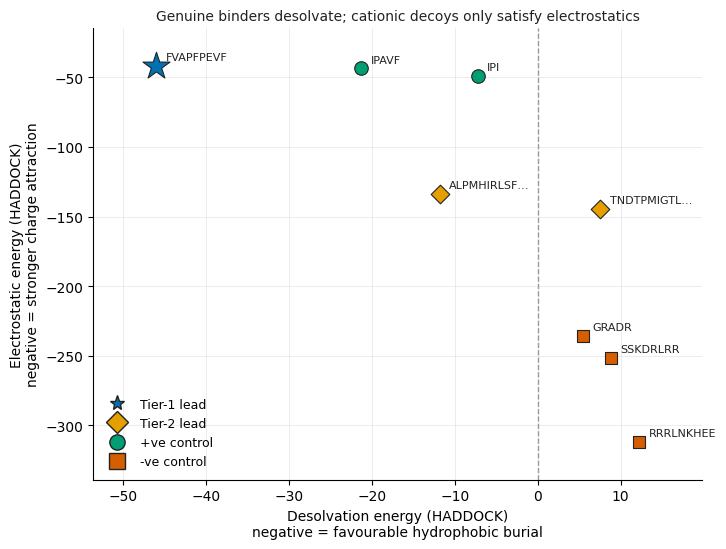

In [4]:
# --- PLOT -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.4, 5.6))

# desolv = 0 divides favourable (hydrophobic burial) from unfavourable
ax.axvline(0, ls="--", lw=1, color="#999999", zorder=1)

for role, pep, desolv, elec in rows:
    colour, marker, size = STYLE[role]
    ax.scatter(desolv, elec, s=size, marker=marker, c=colour,
               edgecolors="#222222", linewidths=0.8, zorder=3)
    ax.annotate(short(pep), (desolv, elec), xytext=(7, 4),
                textcoords="offset points", fontsize=8, color="#222222")

ax.set_xlabel("Desolvation energy (HADDOCK)\nnegative = favourable hydrophobic burial")
ax.set_ylabel("Electrostatic energy (HADDOCK)\nnegative = stronger charge attraction")
ax.set_title("Genuine binders desolvate; cationic decoys only satisfy electrostatics",
             fontsize=10, color="#222222")

# legend in fixed role order (identity carried by colour + shape, never colour alone)
handles = [Line2D([0], [0], marker=STYLE[r][1], color="none", markerfacecolor=STYLE[r][0],
                  markeredgecolor="#222222", markersize=11, label=r) for r in ORDER]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=9)

for sp in ("top", "right"):                # recessive frame + grid
    ax.spines[sp].set_visible(False)
ax.grid(True, lw=0.4, color="#dddddd", zorder=0)
ax.set_axisbelow(True)
ax.margins(x=0.13, y=0.10)                  # room for direct labels near the edges

fig.tight_layout()
fig.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
print(f"-> wrote {OUT_PNG}")
plt.show()   # render inline in the notebook